In [56]:
# Add import 
import sys
import torch 
from torch import nn
from torch import optim
from prodigyopt import Prodigy # proddigy optimizer from https://github.com/konstmish/prodigy?tab=readme-ov-file

import tqdm
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use("Agg")
# matplolib inline 
%matplotlib inline
# allow reload of python modules
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
from dataset.RobotPathDataset.normalizer import MinMaxFeatureNormalizer

from model.models import EMA
import copy
import time

# remove all warnings
import warnings
warnings.filterwarnings("ignore")
from utils.multi_loss import ema_losses

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
# import gdown
# url = 'https://drive.google.com/drive/folders/16UthOas97BntH8ngVSofxgd2JrxSLDZU'
# gdown.download_folder(url)

# Hyperparams Constants

In [58]:
normalizer = MinMaxFeatureNormalizer()
encoder_normalizer = MinMaxFeatureNormalizer()

In [88]:
epochs = 1000
representiation_dim = 64
EXPERIMENT_NAME='1%-data+ema_losses'

In [60]:

CONFIG = {
    # Model configuration
    'representation_dim': representiation_dim, # Dimension of the representation
    'dim_mults':(1, 2, 4, 8), # Dimension multipliers for hidden layers of the model # (1, 4, 8)
    'attention':False, 
    
    # Encoder configuration
    'embeder_num_of_hidden_layers' : 1,
    'encoder_conditional_dim': representiation_dim//2,
    
    # Hyperparameters for training
    'batch_size': 8,
    'num_epochs': epochs,
    'ema': EMA(beta=0.99), # Exponential moving average for the model weights
        ## Optimizer configuration
        'optimizer': Prodigy,
        'optimizer_kwargs': {
            'lr': 1., # ! ONLY FOR PRODIGY OPTIMIZER
            'weight_decay': 0.01, 
            'safeguard_warmup':True,
            'use_bias_correction':True,
            'betas': (0.9, 0.99),
            },
        # Scheduler configuration
        'scheduler': torch.optim.lr_scheduler.CosineAnnealingLR,
        'scheduler_kwargs': {
            # 'gamma': 0.999,
            'T_max': 10, # Total number of iterations
        },

        'multi_loss_warm_up_steps': 2000,
        'loss_weights':{
            'MSE': 0.5, # best for overfitting 1 sample is 0.004
            'ObstacleFreePathLoss': 0.4, # bround truth avg prefromance is 0.00008 with std 0.27
            'GraphBasedConsistencyLoss': 0.1, # ground truth avg prefromance is 0.00031 with std = 1.09
        },

    # Hyperparameters for diffusion process
    'noise_steps': 256,
    'normalize': True,
    'normalizer':normalizer,
    'encoder_normalizer':encoder_normalizer,
    'cfg_scale': 3,


    # Dataset specific configuration
    'n_paths_per_world': 100,
    'n_worlds': 1,
    'n_waypoints': 64, # due to the archtechture has to be a number that is a power of 2 
    'single_world_dataset': False,
    'entire_dataset': True,
    'fraction_of_data': 0.01,

    # logging 
    'visualize_every_n_epochs': 1,
    'stats_every_n_steps': 100,
}

# Dataloader

In [61]:
from dataset import RobotPathDataset

In [62]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
device

cuda:0


device(type='cuda', index=0)

### Normalizer

In [63]:
if CONFIG['single_world_dataset']:
    file = '/home/karim.samir.lotfy/adlr/tum-adlr-ss24-09/data/SingleSphere02_one-world.db'
else:
    file = '/home/karim.samir.lotfy/adlr/tum-adlr-ss24-09/data/SingleSphere02_all.db'
dataset = RobotPathDataset(file, n_paths_per_world=CONFIG['n_paths_per_world'], n_worlds=CONFIG['n_worlds'],  n_waypoints=CONFIG['n_waypoints'],   normalizer=CONFIG['normalizer'], single_world_dataset=CONFIG['single_world_dataset'], entire_dataset=CONFIG['entire_dataset'], fraction_of_data=CONFIG['fraction_of_data'])
print(f' sample shape {dataset[0]["path"].shape} with {len(dataset)} samples')
indx_sample = 5
sample = dataset[indx_sample]

data shape: torch.Size([16532, 64, 2]), min_values: tensor([0, 0], device='cuda:0'), max_values: tensor([10, 10], device='cuda:0'), n_worlds:1000, samples: 16532
 sample shape torch.Size([64, 2]) with 16532 samples


In [64]:
WORLD_IMG = sample['world_img'] 

In [65]:
from torch.utils.data import DataLoader
batch_size = CONFIG['batch_size']
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)
# iterate over the dataset
# get the first batch
sample_batch = next(iter(dataloader))


In [66]:
sample_batch['world_indx'].shape

torch.Size([8])

## Loss Functions

### MSE

### ObstacleFreeLoss

In [67]:
from model import ObstacleFreePathLoss, GraphBasedConsistencyLoss
obstacle_avoidance_loss_fn = ObstacleFreePathLoss(normalizer=CONFIG['normalizer'])
graph_based_consistency_loss_fn = GraphBasedConsistencyLoss()

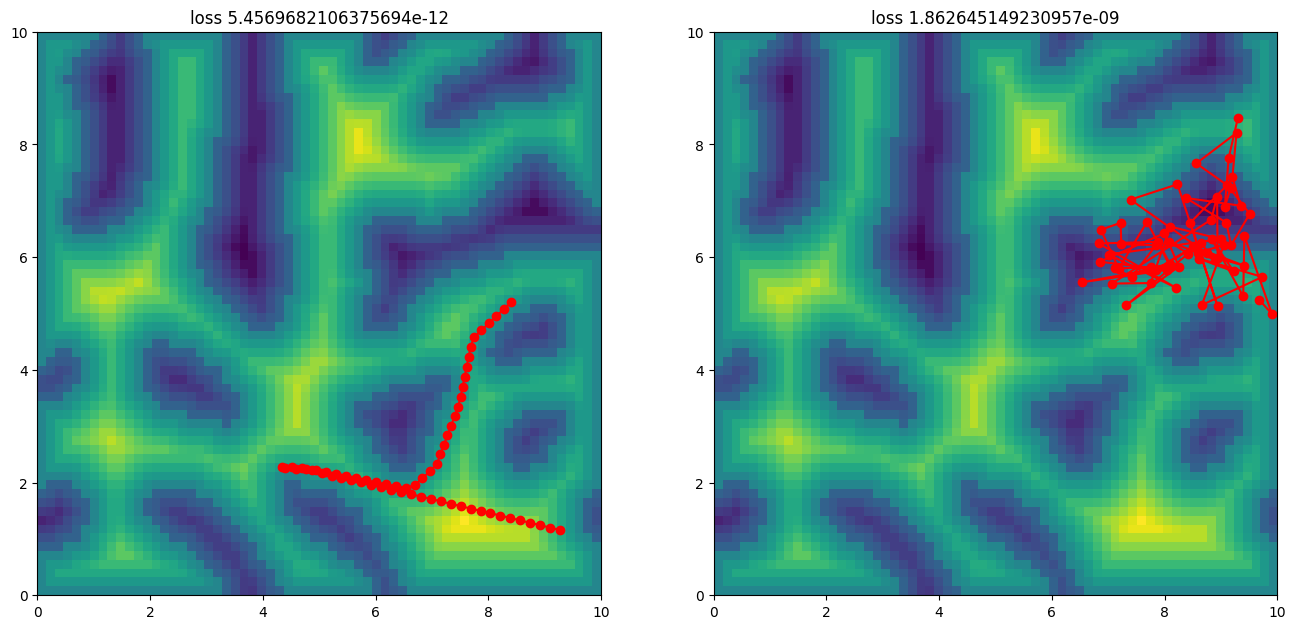

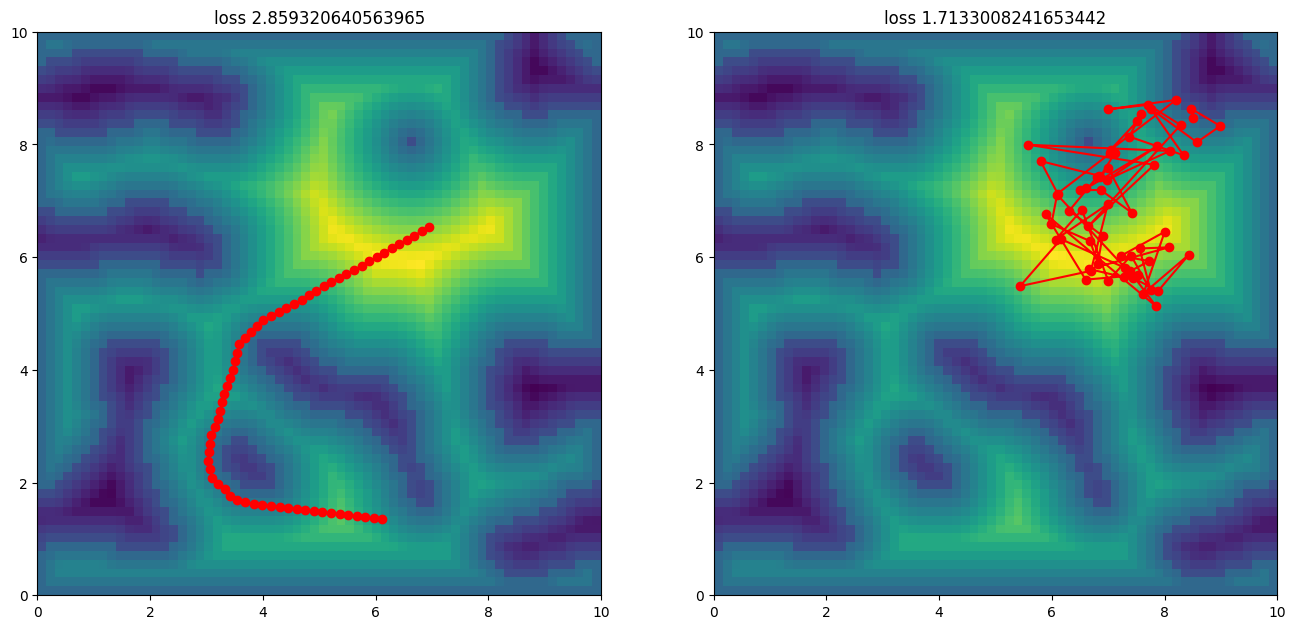

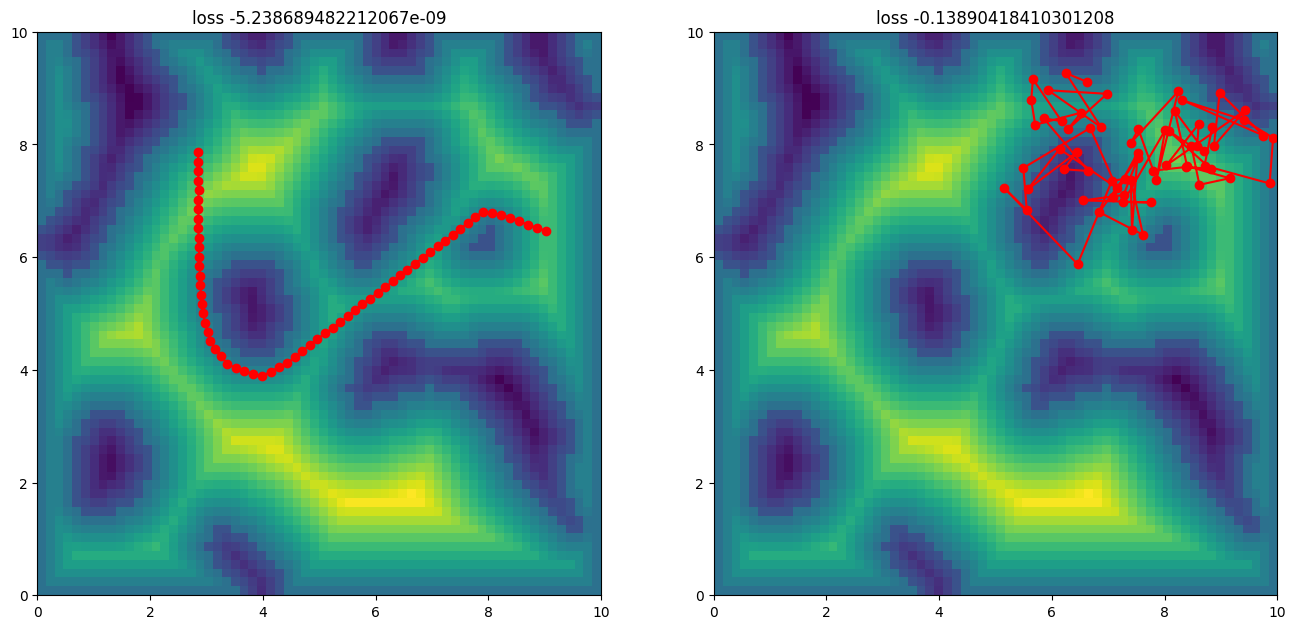

In [68]:
NOISE_TO_ADD_ON_PATH = 0.1
# This loss punishes the model for generating paths that collide with obstacles. 
for i in range(3):
    # create a subpolt for 2 graphs
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    # the 1st will be the path and its distance field + loss value 
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    l = obstacle_avoidance_loss_fn(path, dimg)
    dimg = sample['world_distance_field_img']
    path = sample['og_path'].cpu().detach().numpy()
    axs[0].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[0].plot(path[:, 0], path[:, 1], '-o', color='red')
    axs[0].set_title(f'loss {l}')
    # the 2nd will be the path + some noise and its distance field + loss value
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    noise = torch.randn_like(path) * NOISE_TO_ADD_ON_PATH
    path = path + noise
    l = obstacle_avoidance_loss_fn(path, dimg)
    dimg = sample['world_distance_field_img']
    path_vis = obstacle_avoidance_loss_fn.normalizer.denormalize(path).cpu().detach().numpy()
    axs[1].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[1].plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
    axs[1].set_title(f'loss {l}')


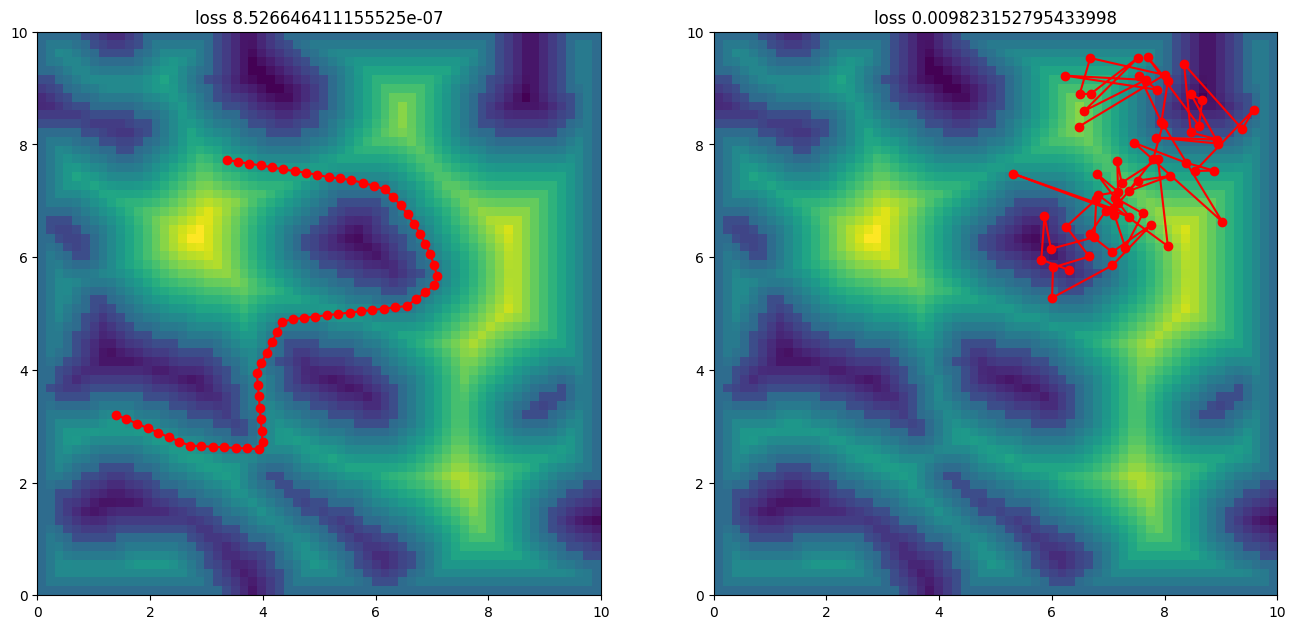

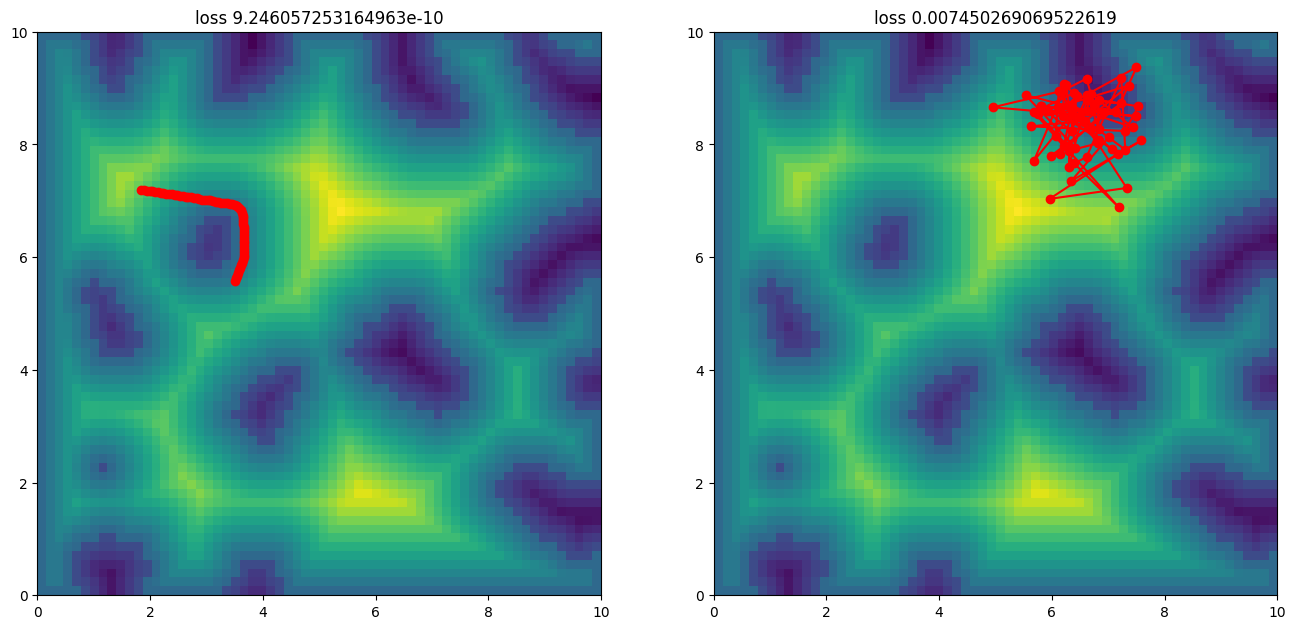

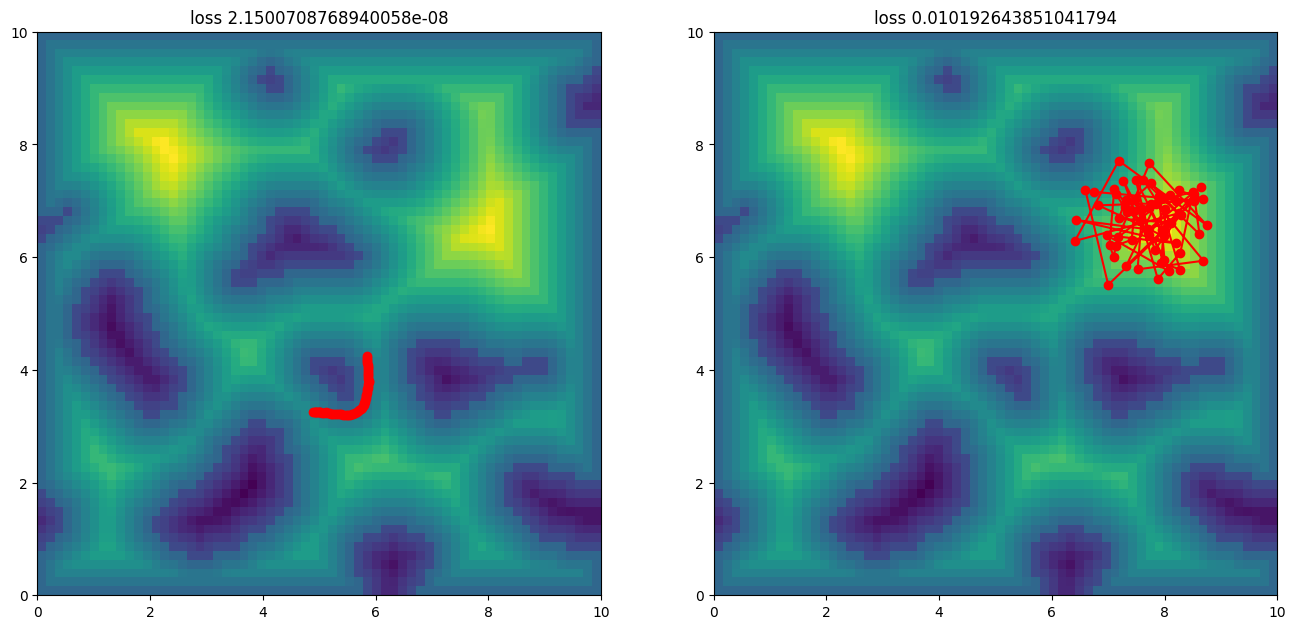

In [69]:
NOISE_TO_ADD_ON_PATH = 0.1
# This loss punishes the model for generating paths that collide with obstacles. 
for i in range(3):
    # create a subpolt for 2 graphs
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    # the 1st will be the path and its distance field + loss value 
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    l = graph_based_consistency_loss_fn(path)
    dimg = sample['world_distance_field_img']
    path = sample['og_path'].cpu().detach().numpy()
    axs[0].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[0].plot(path[:, 0], path[:, 1], '-o', color='red')
    axs[0].set_title(f'loss {l}')
    # the 2nd will be the path + some noise and its distance field + loss value
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    noise = torch.randn_like(path) * NOISE_TO_ADD_ON_PATH
    path = path + noise
    l = graph_based_consistency_loss_fn(path)
    dimg = sample['world_distance_field_img']
    path_vis = obstacle_avoidance_loss_fn.normalizer.denormalize(path).cpu().detach().numpy()
    axs[1].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[1].plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
    axs[1].set_title(f'loss {l}')

# Archtechture

### encoder

In [89]:
from model import WorldIndexEmbeder, FlattenEmbeder, VAEXperiment

In [90]:
# Import pretrained vae model
model_experiment = VAEXperiment.load_from_checkpoint(r'pretrained_models/64-encoder.ckpt')
model_experiment.freeze()
vae_model = model_experiment.model
vae_model.to(device)
vae_model.encoder.to(device)

Sequential(
  (0): Sequential(
    (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (1): Sequential(
    (0): Conv2d(4, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (3): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (4): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(

In [91]:
from model import Encoder
class wrapper_encoder(Encoder):
    def __init__(self, vae_model):
        super(wrapper_encoder, self).__init__()
        self.vae_model = vae_model
    def forward(self, x):
        results = self.vae_model.encode(x)
        mu, log_var = results
        z = self.vae_model.reparameterize(mu, log_var)
        return z

    def decode(self, z):
        return self.vae_model.decode(z)

In [92]:
embedding_dim = CONFIG['encoder_conditional_dim']
# Define the model
sample_input = sample['world_distance_field_img']
encoder = wrapper_encoder(vae_model)

In [93]:
sample_batch = sample_batch
dimgs = sample_batch['world_distance_field_img'].to(device)
encoding = encoder(dimgs)

In [94]:

# assert encoding.shape[1] == CONFIG['encoder_conditional_dim']
encoding.shape

torch.Size([8, 64])

### Model and diffusion

In [95]:
from model import Diffusion, TemporalUnet

In [96]:
# Create the UNet
transition_dim = sample['path'].shape[-1] # transition_dim is the dimension the model should predict. not the timesteps
print(transition_dim)
model = TemporalUnet(horizon=CONFIG['noise_steps'], transition_dim=transition_dim, dim=CONFIG['representation_dim'], dim_mults=CONFIG['dim_mults'],encoder=encoder, attention=CONFIG['attention'],device=device)

2
[ models/temporal ] Channel dimensions: [(2, 64), (64, 128), (128, 256), (256, 512)]
[ models/temporal ] Embedding dimensions: env encoding 32, start_pos encoding 8, end_pos encoding 8, time encoding 16
[(2, 64), (64, 128), (128, 256), (256, 512)]


In [97]:
model.to(device);
model.device

device(type='cuda', index=0)

In [98]:
# create the diffusion model
diffusion = Diffusion(input_shape=sample['path'].shape, noise_steps=CONFIG['noise_steps'], device=device)

In [99]:
# test the model
x = sample_batch
timesteps = diffusion.sample_timesteps(batch_size)
y = model(x['path'], timesteps)
assert y.shape == (batch_size, CONFIG['n_waypoints'], 2)
y.shape

torch.Size([8, 64, 2])

In [100]:
# noise input 
timesteps = diffusion.sample_timesteps(batch_size)
x_t, noise = diffusion.noise_input(sample_batch['path'],timesteps)
x_t.shape, noise.shape

(torch.Size([8, 64, 2]), torch.Size([8, 64, 2]))

In [101]:
import matplotlib.cm as cm

number_of_samples_to_show = 5
# test the model
x = sample_batch['path'][0:number_of_samples_to_show]
timesteps = diffusion.sample_timesteps(number_of_samples_to_show)
y = model(x, timesteps)
# noise input 
timesteps = diffusion.sample_timesteps(number_of_samples_to_show)
x_t, noise = diffusion.noise_input(x,timesteps)
x_t.shape, noise.shape
# plot sample entire batch
colors = cm.rainbow(np.linspace(0, 1, len(x)))
def visualize_diffusion_process(x, x_t, normalizer=None):
    if normalizer:
        x = normalizer.denormalize(x)
        x_t = normalizer.denormalize(x_t)
    x = x.cpu().detach().numpy()
    x_t = x_t.cpu().detach().numpy()
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    for i in range(number_of_samples_to_show):
        ax.plot(x[i, :, 0], x[i, :, 1], 'o-', label='input', color=colors[i])
        ax.plot(x_t[i, :, 0], x_t[i, :, 1], 'o-', label=f'noise t={timesteps[i]}', color=colors[i], alpha=0.5)
    plt.legend()
    plt.show()

print(timesteps)
# visualize_diffusion_process(x, x_t, normalizer=normalizer)
# visualize_diffusion_process(x, x_t, normalizer=None)


tensor([ 10, 231,  22,  11, 244], device='cuda:0')


# Training

### Set up validation and plotting function

In [102]:
# write training loop 
import torch.optim as optim
import torch.nn as nn
from utils.visualize.vae import plot_vae_reconstruciton
from utils.visualize.diffusion import plot_diffusions, plot_noise_and_predicted_noise

### Set up LoggingManager

In [103]:
from LoggingManager import LoggingManager
logging_manager = LoggingManager(experiement_name=EXPERIMENT_NAME)
logging_manager.log_config(CONFIG);

Logging to logs/1%-data+ema_losses/14h-08m-08-07-2024/logs.log


In [104]:
# log the model and input sample 
input_tensor = sample_batch['path']
cond = sample_batch['world_distance_field_img']
# logging_manager.tb_log_graph(model)

# Train 

In [105]:
START_FROM_CHECKPOINT = False
Checkpoint_file = r"logs/big-model+new obstacle loss/20h-39m-21-05-2024/model-epoch_4-loss_0.100-time_21h-22m-21-05-2024"

In [106]:
# train the model

import random


optimizer = CONFIG['optimizer'](model.parameters(), **CONFIG['optimizer_kwargs'])
scheduler = CONFIG['scheduler'](optimizer, **CONFIG['scheduler_kwargs'])
ema = CONFIG['ema']
ema_model = copy.deepcopy(model).eval().requires_grad_(False)
epoch = 0
# Restart from checkpoint 
if START_FROM_CHECKPOINT:
    model, optimizer, scheduler, epoch, loss = logging_manager.load_checkpoint(model, optimizer, scheduler, filename=Checkpoint_file)
    ema.step_ema(ema_model,model)
    logging_manager.log_message(f'Restarting from epoch {epoch} with loss {loss}')
    print(f'Restarting from epoch {epoch} with loss {loss}')


Using decoupled weight decay


In [108]:

for epoch in range(epoch, CONFIG['num_epochs']):
    pbar = tqdm.tqdm(dataloader, total=len(dataloader), leave=True)
    running_loss = 0.0
    # iterate over the dataset
    for i, batch_and_info in enumerate(pbar):
        batch, batch_world_indx, batch_world_img, batch_world_distance_field_img = batch_and_info['path'], batch_and_info['world_indx'], batch_and_info['world_img'], batch_and_info['world_distance_field_img']
        

        # Training step
        model.train()
        optimizer.zero_grad()
        x = batch.to(device)
        cond = batch_world_distance_field_img.to(device)
        start_pos = x[:, 0, :]
        end_pos = x[:, -1, :]
        # if random.random() < 0.1: # in 10% of the time. sample unconditional. This is to use CFG
        #     cond = None
        # preturb input. add noise to it
        timesteps_choosen = diffusion.sample_timesteps(x.shape[0])
        x_t, noise = diffusion.noise_input(x,timesteps_choosen)
        # make sure that 10% of the time the model is trained without some of the conds
        start_pos = start_pos if random.random() > 0.1 else None
        end_pos = end_pos if random.random() > 0.1 else None
        # get model to predict the noise
        pred_noise = model(x_t, timesteps_choosen, cond, start_pos, end_pos)
        pred_path = x + pred_noise
    
        
        # Loss 
        loss_noise_prediction = nn.SmoothL1Loss()(noise, pred_noise)
        loss_obstacle_avoidance = obstacle_avoidance_loss_fn(pred_path, cond)
        loss_graph_based_consistency = graph_based_consistency_loss_fn(pred_path)
        loss_1 = loss_noise_prediction 
        loss_2 = CONFIG['loss_weights']['MSE'] *loss_noise_prediction + CONFIG['loss_weights']['ObstacleFreePathLoss']*loss_obstacle_avoidance + CONFIG['loss_weights']['GraphBasedConsistencyLoss']* loss_graph_based_consistency
        loss = ema_losses(loss_1, loss_2, logging_manager.training_step, CONFIG['multi_loss_warm_up_steps'])
        loss.backward()
        optimizer.step()
        # update the EMA model
        ema.step_ema(ema_model,model)
        running_loss += loss.item()
        logging_manager.plot_losses(loss.item())
        logging_manager.tb_scalar('Loss/MSE', loss_noise_prediction.item())
        logging_manager.tb_scalar('Loss/ObstacleAvoidance', loss_obstacle_avoidance.item())
        logging_manager.tb_scalar('Loss/GraphBasedConsistency', loss_graph_based_consistency.item())
        pbar.set_postfix({'loss': loss.item()})
        if i % CONFIG['stats_every_n_steps'] == 0:

            # plot noise and predicted noise
            plot = plot_noise_and_predicted_noise(x, noise, pred_noise, timesteps_choosen, normalizer=CONFIG['normalizer'])
            logging_manager.tb_log_figure(plot, 'noise_and_predicted_noise', step= i + epoch * len(dataloader))

            # plot noise and predicted noise ema
            # ema_model.eval()
            # pred_noise_ema = ema_model(x_t, timesteps_choosen)
            # plot = plot_noise_and_predicted_noise(x, noise, pred_noise_ema, timesteps_choosen, normalizer=CONFIG['normalizer'])
            # logging_manager.tb_log_figure(plot, 'ema_noise_and_predicted_noise')
            
            # Log optimizer parameters and scheduler parameters
            logging_manager.tb_scalar('optimizer/learning_rate', optimizer.param_groups[0]['lr'])
            logging_manager.tb_scalar('optimizer/d', optimizer.param_groups[0]['d'])
            logging_manager.tb_scalar('optimizer/scheduler-lr', scheduler.get_lr()[0])
            
            # plot reconstruction of encoder 
            sample = cond
            # sample = sample.to(autoencoder.curr_device)
            recon,input_img, mu, var = model.encoder.vae_model.forward(sample)
            plot = plot_vae_reconstruciton(sample, recon)
            logging_manager.tb_log_figure(plot, 'vae_reconstruction')

            

            
    
    logging_manager.log_message(f'Epoch {epoch} Epoch loss: {running_loss/len(dataloader)}')
    print(f'Epoch {epoch} Epoch loss: {running_loss/len(dataloader)}')
    # scheduler
    scheduler.step()
    running_loss = 0.0
    # Validation 
    model.eval()

    if epoch% CONFIG['visualize_every_n_epochs'] == 0:
        logging_manager.save_checkpoint(model, optimizer, scheduler,epoch, loss)

        # # sample model
        # sample from paths 
        n = min(8, len(batch))
        paths = batch[:n]
        cond = batch_world_distance_field_img[:n]
        true_paths = paths
        samples , intermediates = diffusion.sample_from_paths(model, n=n, paths=paths, cond=cond, normalizer=CONFIG['normalizer'])
        plot = plot_diffusions(intermediates, world_imgs=batch_world_img, normalizer=CONFIG['normalizer'], true_paths=true_paths);
        logging_manager.tb_log_figure(plot, 'diffusion_samples')
        # samples, intermediates = diffusion.sample(ema_model,5, cfg_scale=CONFIG['cfg_scale'])
        # plot = plot_diffusions(intermediates, normalizer=CONFIG['normalizer'])
        # logging_manager.tb_log_figure(plot, 'diffusion_samples_ema_cfg', step=epoch)
        for k in range(1):
            
            last_index_for_waypoints = CONFIG['n_waypoints'] - 1
            constraints = {
                0: torch.tensor([0, 0], device=device),
                last_index_for_waypoints: torch.tensor([9, 9],device=device),
            }
            n=CONFIG['batch_size']
            cond = batch_world_distance_field_img.to(device)
            world_imgs = batch_world_img
            # logging_manager.log_message(f'Generating samples from edge to edge with worlds {batch_world_indx}')
            # samples, intermediates = diffusion.sample_with_constraints(model, n=n, constraints=constraints, cond=cond,normalizer=CONFIG['normalizer'])
            # plot = plot_diffusions(intermediates, world_imgs=world_imgs, normalizer=CONFIG['normalizer']);
            # logging_manager.tb_log_figure(plot, f'samples edge to edge World {k}', step=epoch);
            # sample ema model with cfg
            # samples, intermediates = diffusion.sample_with_constraints(ema_model, n=n, constraints=constraints, cond=cond, normalizer=CONFIG['normalizer'], cfg_scale=CONFIG['cfg_scale'])
            # plot = plot_diffusions(intermediates, world_imgs=world_imgs, normalizer=CONFIG['normalizer']);
            # logging_manager.tb_log_figure(plot, f'samples edge to edge World {k} ema+cfg', step=epoch);
            
        # log model embedding space
        # features = model.get_last_embedding()
        # metadata = batch_world_indx
        # metadata should be a list of strings
        # metadata = [f'world {str(i)}' for i in metadata]
        # images = batch_world_img # batch * 64 * 64
        # images = images.unsqueeze(1) # turn to batch * C * H * W
        # logging_manager.tb_log_embedding_space(features, metadata, images)
        
        # # log model weights
        # last_layer_weights = model.final_conv[-1].weight
        # logging_manager.tb_log_histogram(last_layer_weights, 'final layer wieghts')
        # # log model embedding space weights
        # embedding_weights = model.encoder.embedding[-2].weight
        # logging_manager.tb_log_histogram(embedding_weights, 'embedding layer wieghts')
 
        
        
print('Finished Training')    

100%|██████████| 2066/2066 [05:47<00:00,  5.94it/s, loss=0.0867]


Epoch 0 Epoch loss: 0.05869533392688168


255it [00:04, 53.25it/s]
100%|██████████| 2066/2066 [05:00<00:00,  6.88it/s, loss=0.0658]  
INFO:LoggingManager:Epoch 1 Epoch loss: 0.05253287569086887


Epoch 1 Epoch loss: 0.05253287569086887


INFO:LoggingManager:Checkpoint saved to logs/1%-data+ema_losses/14h-08m-08-07-2024/model-epoch_1-loss_0.066-time_14h-20m-08-07-2024
255it [00:04, 52.98it/s]
100%|██████████| 2066/2066 [05:01<00:00,  6.84it/s, loss=0.0495]   
INFO:LoggingManager:Epoch 2 Epoch loss: 0.04820914223424131


...

INFO:LoggingManager:Checkpoint saved to logs/1%-data+ema_losses/14h-08m-08-07-2024/model-epoch_29-loss_0.032-time_16h-46m-08-07-2024
255it [00:04, 52.42it/s]
100%|██████████| 2066/2066 [03:23<00:00, 10.16it/s, loss=0.0554]   
INFO:LoggingManager:Epoch 30 Epoch loss: 0.036018105799427824


Epoch 30 Epoch loss: 0.036018105799427824


INFO:LoggingManager:Checkpoint saved to logs/1%-data+ema_losses/14h-08m-08-07-2024/model-epoch_30-loss_0.055-time_16h-50m-08-07-2024
255it [00:04, 52.49it/s]
100%|██████████| 2066/2066 [05:13<00:00,  6.59it/s, loss=0.0409]   
INFO:LoggingManager:Epoch 31 Epoch loss: 0.03606462799777193


Epoch 31 Epoch loss: 0.03606462799777193


INFO:LoggingManager:Checkpoint saved to logs/1%-data+ema_losses/14h-08m-08-07-2024/model-epoch_31-loss_0.041-time_16h-55m-08-07-2024
255it [00:04, 52.21it/s]
 65%|██████▌   | 1352/2066 [06:40<6:46:08, 34.13s/it, loss=0.0637] 